# Лабораторная работа №5: Градиентный бустинг

Выполнил студент группы 6401-010302D Смирнов Андрей Александрович




In [1]:
pip install shap

In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline, make_pipeline

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.
   > Датасет должен содержать категориальные и количественные признаки.


In [84]:
# Датасет для бинарной классификации
df_bin = pd.read_csv("/content/bank-full.csv", delimiter=';')
pd.set_option('display.max_columns', None)

df_bin

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [4]:
# Датасет для регрессии
df_reg = pd.read_csv("/content/student-mat.csv", delimiter=';')

df_reg

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


## 2. Датасет и подготовка данных:
   - Привести описание датасета.
   - Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".
   - Нормализовать численные данные.
   - Закодировать категориальные признаки при необходимости.
     > Кодировать признаки или нет для `XGBoost`/`CatBoost` &ndash; на ваше усмотрение.  
     > В явном виде текстом описать применяется ли кодирование категориальных признаков и с какими параметрами.
   - Разбить выборку на обучающую и тестовую.
   - При наличии дисбаланса классов снизить дисбаланс классов в обучающей выборке (***см. [примечание](#примечание)***).

**Бинарная классификация**:

Датасет содержит данные о результатах маркетинговой программы банка, полученных в ходе звонков клиентам.

Целевой признак:
- Бинарная классификация - y ('yes'/'no' согласился ли клиент на депозит)

| Признак | Описание | Тип / Единицы измерения  
   | --- | --- | --- |  
age |	Возраст	|	Числовой
job | Работа | Категориальный
marital | Семейный статус | Категориальный
education | Уровень образования | Категориальныый
default | Есть ли невыплаченный кредит | Бинарный
balance | Среднегодовой баланс | Числовой
housing | Есть ли ипотека | Бинарный
loan | Есть ли кредит на личные цели | Бинарный
contact | Способ контакта | Категориальный
day | День последнего контакта | Дата
month | Месяц последнего контакта | Дата
duration | Длительность контакта | Числовой
campaign | Число контактов с клиентом за текущую компанию | Числовой
pdays | Число дней с последнего контакта | Числовой, -1 если это первый контакт
previous | Число контактов с клиентом за время предыдущих компаний | Числовой
poutcome | Исход предыдущей компании | Категориальный

In [85]:
df_bin = df_bin.drop(columns=['duration', 'pdays', 'month', 'day']) # Убираем лишние признаки

df_bin.dropna()

num_cols_bin = [var for var in df_bin.columns if df_bin[var].dtype == 'int64']
cat_cols_bin = [var for var in df_bin.columns if df_bin[var].dtype == 'object']
cat_cols_bin.remove('y')

len_max = max([len(col) for col in cat_cols_bin])
for col in cat_cols_bin:
    print(f"{col:<{len_max}} labels: {len(df_bin[col].unique())}")

job       labels: 12
marital   labels: 3
education labels: 4
default   labels: 2
housing   labels: 2
loan      labels: 2
contact   labels: 3
poutcome  labels: 4


In [86]:
# Нормирование признаков
scaler = MinMaxScaler()

df_bin[num_cols_bin] = scaler.fit_transform(df_bin[num_cols_bin])

df_bin

,age,job,marital,education,default,balance,housing,loan,contact,campaign,previous,poutcome,y
0,0.519481,management,married,tertiary,no,0.092259,yes,no,unknown,0.000000,0.000000,unknown,no
1,0.337662,technician,single,secondary,no,0.073067,yes,no,unknown,0.000000,0.000000,unknown,no
2,0.194805,entrepreneur,married,secondary,no,0.072822,yes,yes,unknown,0.000000,0.000000,unknown,no
3,0.376623,blue-collar,married,unknown,no,0.086476,yes,no,unknown,0.000000,0.000000,unknown,no
4,0.194805,unknown,single,unknown,no,0.072812,no,no,unknown,0.000000,0.000000,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.428571,technician,married,tertiary,no,0.080293,no,no,cellular,0.032258,0.000000,unknown,yes
45207,0.688312,retired,divorced,primary,no,0.088501,no,no,cellular,0.016129,0.000000,unknown,yes
45208,0.701299,retired,married,secondary,no,0.124689,no,no,cellular,0.064516,0.010909,success,yes
45209,0.506494,blue-collar,married,secondary,no,0.078868,no,no,telephone,0.048387,0.000000,unknown,no


In [87]:
# Разбиение на обучающую и тестовую выборки
y_bin = df_bin['y'].map({'no':0, 'yes':1})
X_bin = df_bin.drop('y', axis=1)

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)

**Дисбаланс классов**:
Для борьбы с дисбалансом классов будем использовать пайплайн imblearn с SMOTENC

In [88]:
# Дисбаланс классов
y_bin_ratio = pd.DataFrame(y_bin.value_counts())
y_bin_ratio['ratio'] = y_bin.value_counts() / len(y_bin)
y_bin_ratio

,count,ratio
y,,
0,39922,0.883015
1,5289,0.116985


**Регрессия**:


Датасет содержит различные данные об учениках двух школ в Португалии.

Целевой признак:
- Регрессия - G3 (оценка по математике за год (0-20))

| Признак | Описание | Тип / Единицы измерения
   | --- | --- | --- |
school | Школа ученика | Категориальный, бинарный: 'GP' / 'MS'
sex | Пол ученика |Категориальный, бинарный: 'F' / 'M'
age | Возраст ученика |Числовой, годы (15–22)
address |Тип места проживания | Категориальный, бинарный: 'U' (город) / 'R' (село)
famsize |Размер семьи |Категориальный, бинарный: 'LE3' (≤3) / 'GT3' (>3)
Pstatus |Статус совместного проживания родителей |Категориальный, бинарный: 'T' (вместе) / 'A' (раздельно)
Medu |Уровень образования матери |Порядковый, шкала 0–4 (0: нет, 1: начальное, 2: 5–9 кл., 3: среднее, 4: высшее)
Fedu |Уровень образования отца | Порядковый, шкала 0–4 (аналогично Medu)
Mjob |Работа матери |Категориальный, номинальный: 'teacher', 'health', 'services', 'at_home', 'other'
Fjob |Работа отца |Категориальный, номинальный (аналогично Mjob)
reason|Причина выбора школы |Категориальный, номинальный: 'home', 'reputation', 'course', 'other'
guardian | Опекун ученика | Категориальный, номинальный: 'mother', 'father', 'other'
traveltime| Время пути от дома до школы | Порядковый, шкала 1–4 (1: <15 мин, 2: 15–30 мин, 3: 30–60 мин, 4: >1 ч)
studytime | Еженедельное время на учёбу | Порядковый, шкала 1–4 (1: <2 ч, 2: 2–5 ч, 3: 5–10 ч, 4: >10 ч)
failures | Количество прошлых неудач (несданных предметов) | Числовой, дискретный: 1, 2, или 4 (если ≥3)
schoolsup | Дополнительная образовательная поддержка от школы | Бинарный: 'yes' / 'no'
famsup | Образовательная поддержка от семьи | Бинарный: 'yes' / 'no'
paid | Дополнительные платные занятия по предмету | Бинарный: 'yes' / 'no'
activities | Участие во внеклассных мероприятиях | Бинарный: 'yes' / 'no'
nursery | Посещение детского сада | Бинарный: 'yes' / 'no'
higher | Планирует ли получать высшее образование | Бинарный: 'yes' / 'no'
internet | Наличие интернета дома | Бинарный: 'yes' / 'no'
romantic | Наличие романтических отношений | Бинарный: 'yes' / 'no'
famrel | Качество семейных отношений | Порядковый, шкала 1–5 (1: очень плохо, 5: отлично)
freetime | Количество свободного времени после школы | Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
goout | Частота встреч с друзьями | Порядковый, шкала 1–5 (1: очень редко, 5: очень часто)
Dalc | Потребление алкоголя в будние дни |Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
Walc | Потребление алкоголя в выходные дни | Порядковый, шкала 1–5 (аналогично Dalc)
health | Текущее состояние здоровья | Порядковый, шкала 1–5 (1: очень плохое, 5: отличное)
absences | Количество пропусков школы | Числовой, счётчик (0–93)



In [5]:
df_reg = df_reg.drop(columns=['G1', 'G2']) # Убираем лишние признаки

cat_cols_reg = [var for var in df_reg.columns if df_reg[var].dtype == 'object']
num_cols_reg = [var for var in df_reg.columns if df_reg[var].dtype == 'int64']
num_cols_reg.remove('G3')

# Определяем бинарные и небинарные категориальные признаки
len_max = max([len(col) for col in cat_cols_reg])
for col in cat_cols_reg:
    print(f"{col:<{len_max}} labels: {len(df_reg[col].unique())}")

school     labels: 2
sex        labels: 2
address    labels: 2
famsize    labels: 2
Pstatus    labels: 2
Mjob       labels: 5
Fjob       labels: 5
reason     labels: 4
guardian   labels: 3
schoolsup  labels: 2
famsup     labels: 2
paid       labels: 2
activities labels: 2
nursery    labels: 2
higher     labels: 2
internet   labels: 2
romantic   labels: 2


In [6]:
# Нормирование признаков
scaler = MinMaxScaler()

df_reg[num_cols_reg] = scaler.fit_transform(df_reg[num_cols_reg])

df_reg

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,0.428571,U,GT3,A,1.00,1.00,at_home,teacher,...,no,no,0.75,0.50,0.75,0.00,0.00,0.50,0.080000,6
1,GP,F,0.285714,U,GT3,T,0.25,0.25,at_home,other,...,yes,no,1.00,0.50,0.50,0.00,0.00,0.50,0.053333,6
2,GP,F,0.000000,U,LE3,T,0.25,0.25,at_home,other,...,yes,no,0.75,0.50,0.25,0.25,0.50,0.50,0.133333,10
3,GP,F,0.000000,U,GT3,T,1.00,0.50,health,services,...,yes,yes,0.50,0.25,0.25,0.00,0.00,1.00,0.026667,15
4,GP,F,0.142857,U,GT3,T,0.75,0.75,other,other,...,no,no,0.75,0.50,0.25,0.00,0.25,1.00,0.053333,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,0.714286,U,LE3,A,0.50,0.50,services,services,...,no,no,1.00,1.00,0.75,0.75,1.00,0.75,0.146667,9
391,MS,M,0.285714,U,LE3,T,0.75,0.25,services,services,...,yes,no,0.25,0.75,1.00,0.50,0.75,0.25,0.040000,16
392,MS,M,0.857143,R,GT3,T,0.25,0.25,other,other,...,no,no,1.00,1.00,0.50,0.50,0.50,0.50,0.040000,7
393,MS,M,0.428571,R,LE3,T,0.75,0.50,services,other,...,yes,no,0.75,0.75,0.00,0.50,0.75,1.00,0.000000,10


In [7]:
y_reg = df_reg['G3']
X_reg = df_reg.drop('G3', axis=1)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

## 3. Для каждого из классификаторов ($AdaBoost$, $GradientBoostingClassifier$, $XGBoost$, $CatBoost$):
   - С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели.
     > Как минимум основных: `n_estimators`/`iterations`, `learning_rate`, `depth`, параметры регуляризации $L^1$, $L^2$.
   - Построить `ROC` и `Precision-Recall` графики для обучающей и тестовой выборок.
   - Вывести метрики на тестовом наборе (как минимум `classification_report`, другие по желанию).
   - Сравнить модели, выбрать лучшую.

**Дисбаланс классов**:

Проблема дисбаланса классов решается ресемплингом с помощью SMOTENC в пайплайне, для CatBoost со встроенным gridsearch используется параметр

In [14]:
from ipywidgets import *
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def roc_pr_curve_plot(model, X_train, y_train, X_test, y_test, model_name, param_str=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    if len(param_str) > 0:
        param_str = ", " + param_str

    display = RocCurveDisplay.from_estimator(
        model, X_train, y_train, name=f"{model_name} train", ax=ax[0]
    )
    display = RocCurveDisplay.from_estimator(
        model, X_test, y_test, name=f"{model_name} test", ax=ax[0]
    )
    ax[0].set_title(f"ROC curve{param_str}")
    ax[0].set_aspect('equal', adjustable='box')

    display = PrecisionRecallDisplay.from_estimator(
        model, X_train, y_train, name=f"{model_name} train", ax=ax[1]
    )
    display = PrecisionRecallDisplay.from_estimator(
        model, X_test, y_test, name=f"{model_name} test", ax=ax[1]
    )
    ax[1].set_title(f"PR curve{param_str}")
    ax[1].set_aspect('equal', adjustable='box')

    return fig, ax

### **AdaBoost**

In [17]:
%%time
ohe = OneHotEncoder(dtype=bool, handle_unknown='ignore')
sm = SMOTENC(categorical_features=cat_cols_bin, categorical_encoder=ohe, random_state=42)
abc_model = AdaBoostClassifier(random_state=42)

imb_pipeline = ImbPipeline(steps=[('sampling', sm), ('encoding', ohe), ('classification', abc_model)])

param_grid_ada = {
    'classification__n_estimators': [50, 100, 150],
    'classification__learning_rate': [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(
    imb_pipeline, param_grid_ada, cv = 5, n_jobs = -1
)

grid_ada.fit(X_bin_train, y_bin_train)

y_pred_ada = grid_ada.predict(X_bin_test)

print(f"Лучшие гиперпараметры AdaBoostClassifier:\n {grid_ada.best_params_}")
print(f"\n--- Показатели на тестовой выборке --- \n")
print(classification_report(y_bin_test, y_pred_ada))


Лучшие гиперпараметры AdaBoostClassifier:
 {'classification__learning_rate': 1, 'classification__n_estimators': 150}

--- Показатели на тестовой выборке --- 

              precision    recall  f1-score   support

           0       0.93      0.76      0.84      7952
           1       0.24      0.55      0.33      1091

    accuracy                           0.74      9043
   macro avg       0.58      0.66      0.58      9043
weighted avg       0.84      0.74      0.77      9043

CPU times: user 16.2 s, sys: 458 ms, total: 16.7 s
Wall time: 5min 50s


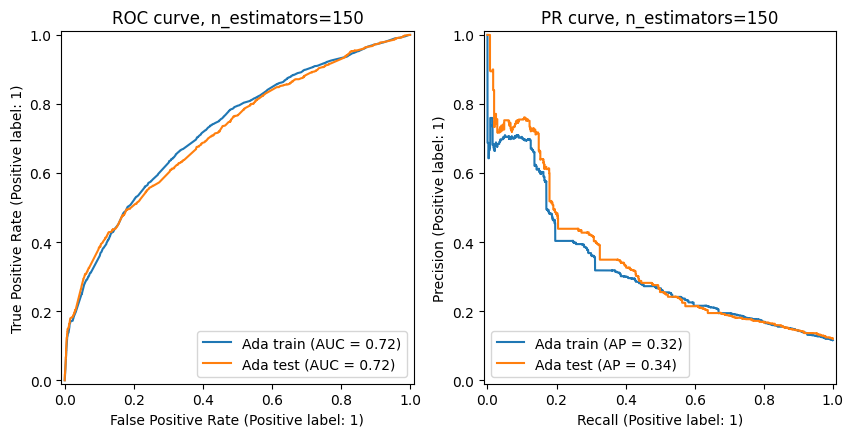

In [18]:
fig, ax = roc_pr_curve_plot(grid_ada, X_bin_train, y_bin_train, X_bin_test, y_bin_test,
                            "Ada", f"n_estimators={grid_ada.best_params_['classification__n_estimators']}")

### **GradientBoostingClassifier**

In [20]:
%%time
gbc_model = GradientBoostingClassifier(random_state=42)

imb_pipeline = ImbPipeline(steps=[('sampling', sm), ('encoding', ohe), ('classification', gbc_model)])

param_grid_gbc = {
    'classification__n_estimators': [50, 100, 150],
    'classification__learning_rate': [0.1, 1],
    'classification__max_depth': [3, 4]
}

grid_gbc = GridSearchCV(
    imb_pipeline, param_grid_gbc, cv = 5, n_jobs = -1
)

grid_gbc.fit(X_bin_train, y_bin_train)

y_pred_gbc = grid_gbc.predict(X_bin_test)

print(f"Лучшие гиперпараметры GradientBoostingClassifier:\n {grid_gbc.best_params_}")
print(f"\n--- Показатели на тестовой выборке --- \n")
print(classification_report(y_bin_test, y_pred_gbc))


Лучшие гиперпараметры GradientBoostingClassifier:
 {'classification__learning_rate': 1, 'classification__max_depth': 3, 'classification__n_estimators': 150}

--- Показатели на тестовой выборке --- 

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      7952
           1       0.38      0.30      0.33      1091

    accuracy                           0.86      9043
   macro avg       0.64      0.62      0.63      9043
weighted avg       0.84      0.86      0.85      9043



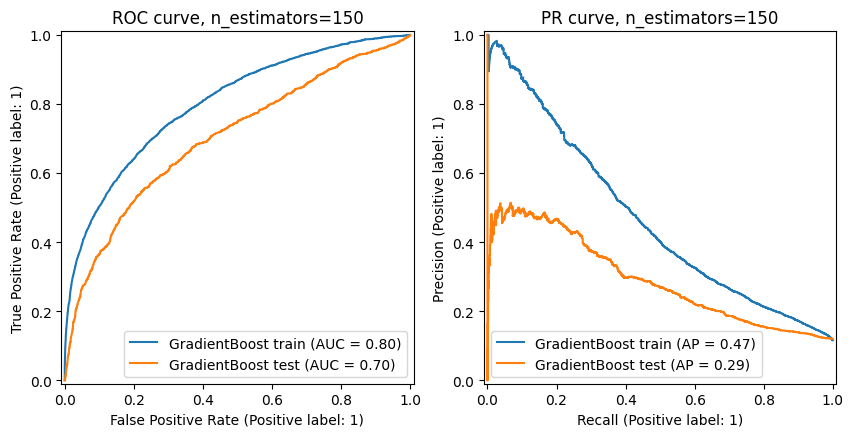

In [21]:
fig, ax = roc_pr_curve_plot(grid_gbc, X_bin_train, y_bin_train, X_bin_test, y_bin_test,
                            "GradientBoost", f"n_estimators={grid_gbc.best_params_['classification__n_estimators']}")

### **XGBoost**

In [23]:
%%time
xgbc_model = XGBClassifier(random_state=42, objective='binary:logistic')

imb_pipeline = ImbPipeline(steps=[('sampling', sm), ('encoding', ohe), ('classification', xgbc_model)])

param_grid_xgbc = {
    'classification__n_estimators': [50, 100, 150],
    'classification__learning_rate': [0.01, 0.1],
    'classification__max_depth': [3, 5],
    'classification__reg_lambda': [0.1, 1],
    'classification__reg_alpha': [0.1, 1]
}

grid_xgbc = GridSearchCV(
    imb_pipeline, param_grid_xgbc, cv = 5, n_jobs = 1, error_score='raise'
)

grid_xgbc.fit(X_bin_train, y_bin_train)

y_pred_xgbc = grid_xgbc.predict(X_bin_test)

print(f"Лучшие гиперпараметры XGBClassifier:\n {grid_xgbc.best_params_}")
print(f"\n--- Показатели на тестовой выборке --- \n")
print(classification_report(y_bin_test, y_pred_xgbc))


Лучшие гиперпараметры XGBClassifier:
 {'classification__learning_rate': 0.1, 'classification__max_depth': 5, 'classification__n_estimators': 150, 'classification__reg_alpha': 0.1, 'classification__reg_lambda': 0.1}

--- Показатели на тестовой выборке --- 

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      7952
           1       0.35      0.44      0.39      1091

    accuracy                           0.83      9043
   macro avg       0.64      0.67      0.65      9043
weighted avg       0.85      0.83      0.84      9043

CPU times: user 50min 33s, sys: 37.4 s, total: 51min 10s
Wall time: 35min 23s


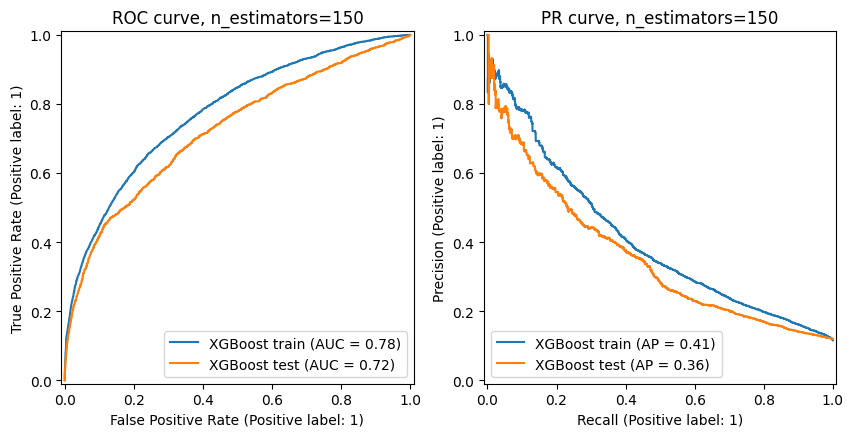

In [26]:
fig, ax = roc_pr_curve_plot(grid_xgbc, X_bin_train, y_bin_train, X_bin_test, y_bin_test,
                            "XGBoost", f"n_estimators={grid_xgbc.best_params_['classification__n_estimators']}")

### **CatBoost**

In [24]:
cbc_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    loss_function='Logloss',
    auto_class_weights='Balanced',
    cat_features=cat_cols_bin
)

param_grid_cbc = {
    'iterations': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'depth': [3, 4, 5],
    'l2_leaf_reg': [0.1, 0.5, 1]
}

grid_result = cbc_model.grid_search(
    param_grid_cbc,
    X=X_bin_train,
    y=y_bin_train,
    cv=5,
    partition_random_seed=42,
    refit=True,
    verbose=False
)

y_pred_cbc = cbc_model.predict(X_bin_test)

print(f"Лучшие гиперпараметры:\n {grid_result['params']}")
print(f"\n--- Показатели на тестовой выборке --- \n")
print(classification_report(y_bin_test, y_pred_cbc))


bestTest = 0.638089219
bestIteration = 49


bestTest = 0.5919436075
bestIteration = 49


bestTest = 0.5957675401
bestIteration = 16


bestTest = 0.6380948579
bestIteration = 49


bestTest = 0.5915341147
bestIteration = 49


bestTest = 0.5939045617
bestIteration = 16


bestTest = 0.6382196432
bestIteration = 49


bestTest = 0.5904102472
bestIteration = 49


bestTest = 0.5914063664
bestIteration = 22


bestTest = 0.6192983889
bestIteration = 99


bestTest = 0.5897497862
bestIteration = 92


bestTest = 0.5957675401
bestIteration = 16


bestTest = 0.6194201085
bestIteration = 99


bestTest = 0.5888172671
bestIteration = 99


bestTest = 0.5939045617
bestIteration = 16


bestTest = 0.6194736129
bestIteration = 99


bestTest = 0.5882783031
bestIteration = 98


bestTest = 0.5914063664
bestIteration = 22


bestTest = 0.6088738236
bestIteration = 149


bestTest = 0.5885740482
bestIteration = 147


bestTest = 0.5957675401
bestIteration = 16


bestTest = 0.6096148047
bestIteration = 149


bestTes

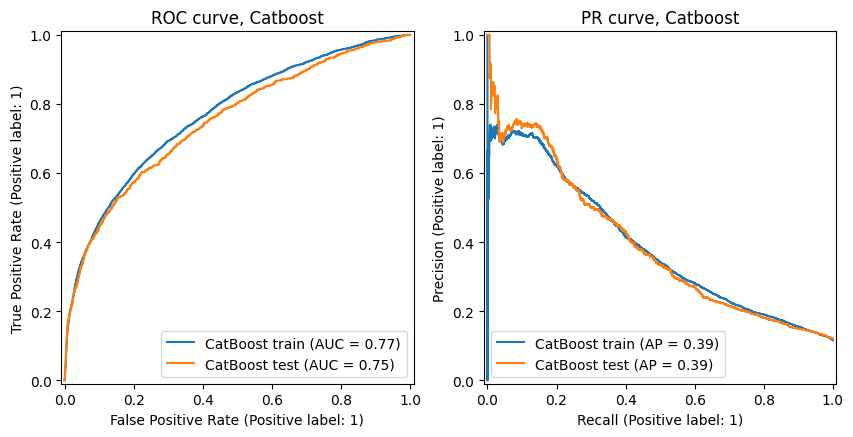

In [25]:
fig, ax = roc_pr_curve_plot(cbc_model, X_bin_train, y_bin_train, X_bin_test, y_bin_test,
                            "CatBoost", f"Catboost")

**Сравнение моделей**:

В целом модели показали схожие результаты на примерно сопоставимых параметрах обучения. Сравним результаты классификации моделями после подбора гиперпараметров и выберем лучшую модель. В качестве показателя, по которому будем выбирать лучшую модель, возьмем **AUC-ROC** (Area under ROC curve), показывающую на тестовой выборке.

| Модель | ROC-AUC (обуч.) | ROC-AUC (тест.)
| --- | --- | --- |
| AdaBoost | 0,72 | 0,72
| GradientBoostClassifier | 0,80 | 0,70
| XGBClassifier | 0,78 | 0,72
| **CatBoostClassifier** | 0,77 | **0,75**


Хотя AUC на обучающей выборке у GradientBoostClassifier выше, на валидационной выборке CatBoost показал результат выше прочих моделей. Далее будем использовать его

## 4. Важность признаков:

In [31]:
import shap

In [29]:
cb_model = CatBoostClassifier(depth=3, learning_rate=0.1, l2_leaf_reg=1, iterations=1000, cat_features=cat_cols_bin)

cb_model.fit(X_bin_train, y_bin_train, verbose=False)

CatBoostClassifier(cat_features=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome'], depth=3, iterations=1000, l2_leaf_reg=1, learning_rate=0.1)

   - С использованием `shap.TreeExplainer` получить $SHAP$-значения для лучшей модели.

In [32]:
tree_explainer = shap.TreeExplainer(cb_model)
te_shap_values = tree_explainer.shap_values(X_bin_train)

  - Построить график `shap.plots.force` для одного объекта выборки и для среза произвольного размера.

In [33]:
# График для одного объекта
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, te_shap_values[3,:], X_bin_train.iloc[3,:])

HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

HTML(value='<div style=\'background-color: Lavender;\'><script charset=\'utf-8\'>/*! For license information p…

In [34]:
# График для среза в 400 объектов
shap_fp = shap.plots.force(tree_explainer.expected_value, te_shap_values[:400], X_bin_train[:400])

HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

HTML(value='<div style=\'background-color: Lavender;\'><script charset=\'utf-8\'>/*! For license information p…

 - Построить график `shap.plots.bar` для одного объекта выборки.

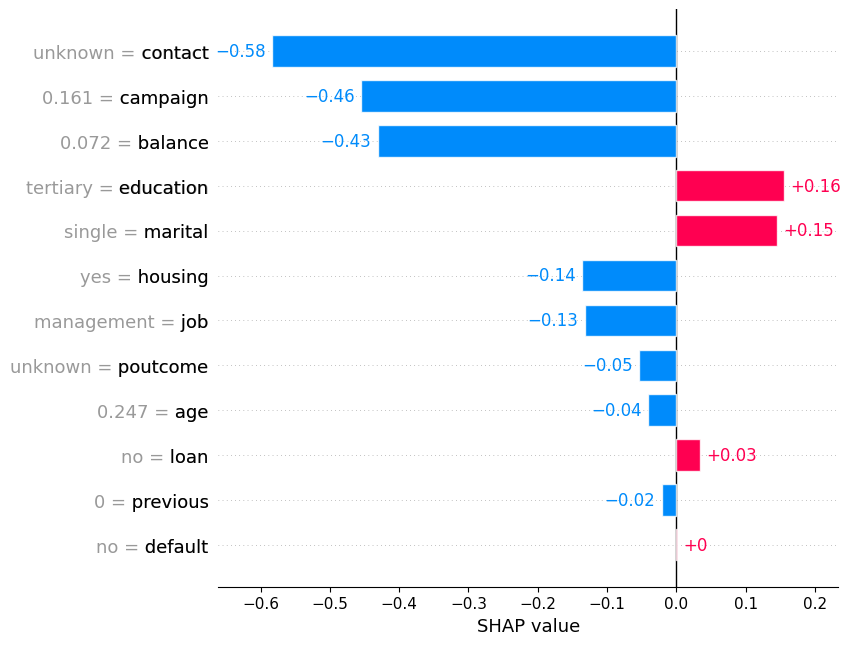

In [35]:
te_df_shap_values = tree_explainer(X_bin_train)
fig, ax = plt.subplots()
shap_bp = shap.plots.bar(te_df_shap_values[3], max_display=X_bin_train.shape[1])
fig.tight_layout()

  - Построить график `shap.plots.waterfall` для одного объекта выборки.

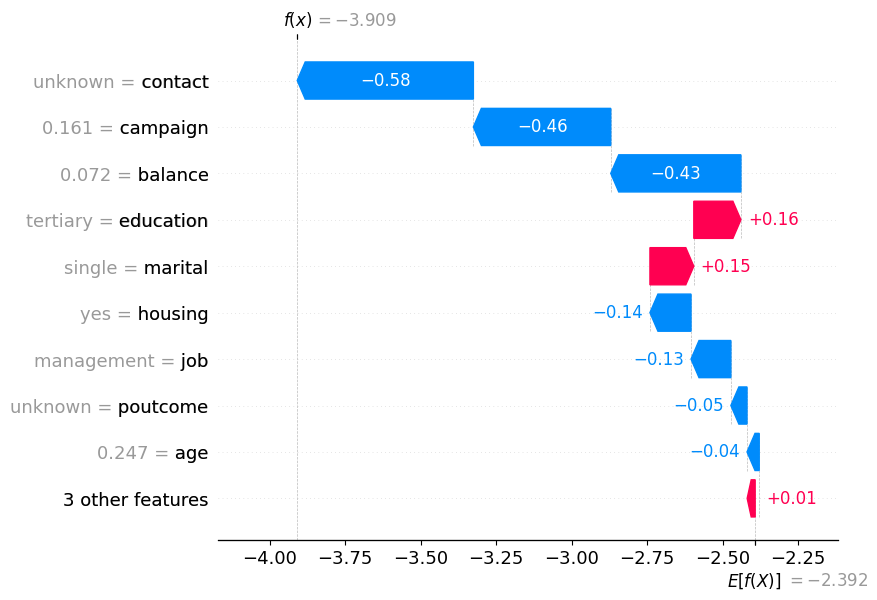

In [36]:
te_df_shap_values_expln = te_df_shap_values[3]
fig, ax = plt.subplots()
shap.plots.waterfall(te_df_shap_values_expln)
fig.tight_layout()

- Построить 2 графика `shap.plots.scatter` для какого-нибудь признака. На одном раскрасить относительно себя, на втором &ndash; относительно другого признака.

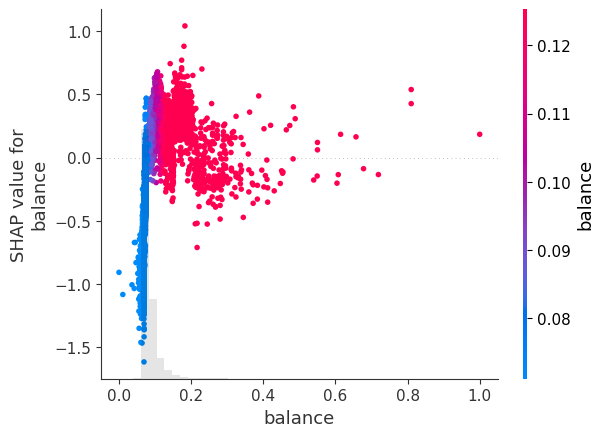

In [37]:
fig, ax = plt.subplots()
shap.plots.scatter(te_df_shap_values[:, "balance"], color=te_df_shap_values[:, "balance"], ax=ax)
fig.tight_layout()

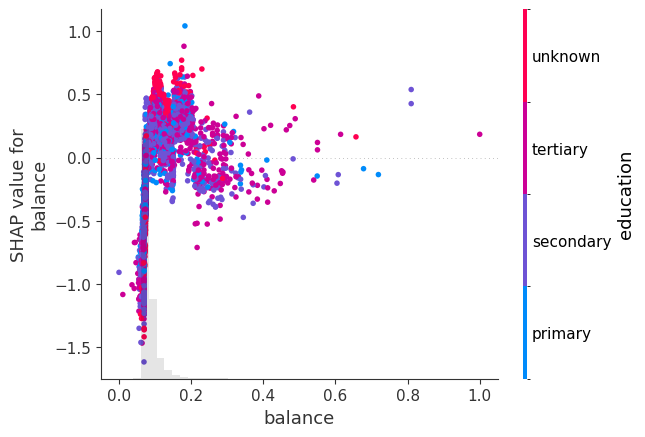

In [38]:
fig, ax = plt.subplots()
shap.plots.scatter(te_df_shap_values[:, "balance"], color=te_df_shap_values[:, "education"], ax=ax)
fig.tight_layout()

- Построить график `shap.plots.beeswarm` для всех признаков.

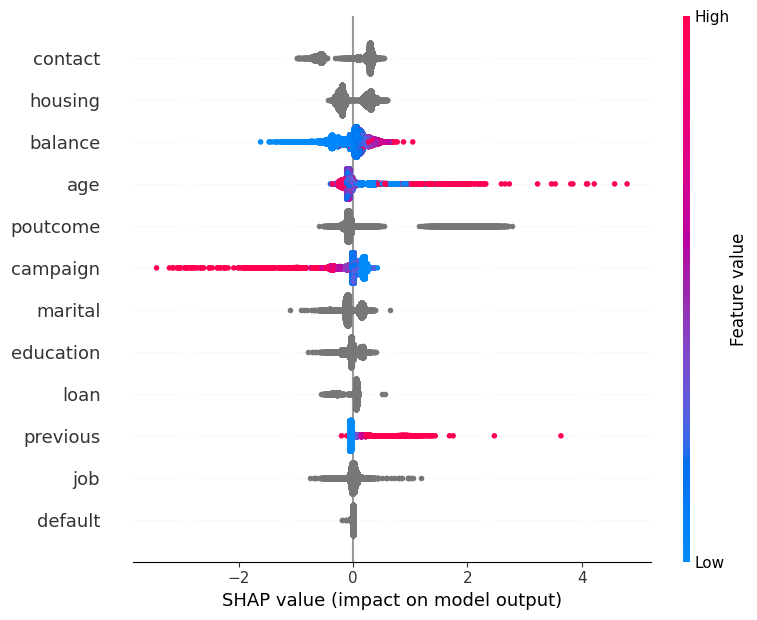

In [39]:
fig, ax = plt.subplots()
shap.plots.beeswarm(te_df_shap_values, max_display=X_bin_train.shape[1], show=False)
fig.tight_layout()

- Построить график `shap.plots.bar` для всех признаков.

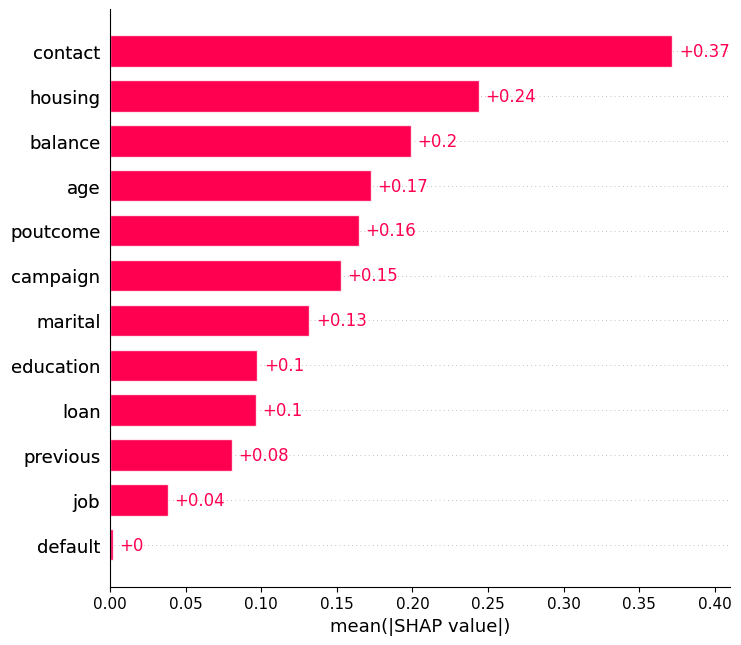

In [40]:
fig, ax = plt.subplots()
shap_bp = shap.plots.bar(te_df_shap_values, max_display=X_bin_train.shape[1])
fig.tight_layout()

- На основании двух последних графиков и/или используя `feature_importance` (или ***см. [примечание](#примечание)***) отфильтровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель.

**Отбор признаков**:

По `bar` графику видно, что наиболее важными признаками (по среднему значению **SHAP**) для принятия решений по тому, возьмет ли клиент кредит, являются **contact** (способ контакта с клиентом), **housing** (наличие ипотеки), **balance** (баланс клиента), **age** (возраст), **poutcome** (исход предыдущей компании) и **campaign** (число контактов с клиентом за текущую компанию).

Из `beeswarm` графика можно выделить логические взаимосвязи между числовыми признаками и тем, как сильно их значение влияет на предсказание модели.
Видно, что более крайние значения признаков сильнее влияют на предсказание модели.

Можно наблюдать интересные зависимости. Например, если высокий возраст клиента может как снижать вероятность того, что он возьмет кредит (у него есть деньги и кредит ему не нужен), так и повышать (клиент платежеспособен и может себе позволить взять кредит). Высокий баланс на счете скорее повышает вероятность, что клиент возьмет кредит. Чем больше раз с клиентом связывались за текущую компанию, тем меньше вероятность, что он возьмет кредит. Чем больше число контактов за предыдущие компании, тем больше они могут снижать или повышать вероятность, что клиент возьмет кредит.

In [43]:
# Обучим модель на отобранных признаках
selected_features = ['contact', 'housing', 'balance', 'age', 'poutcome', 'campaign']

cb_model_f = CatBoostClassifier(depth=3, learning_rate=0.1, l2_leaf_reg=1, iterations=1000, cat_features=['contact', 'housing', 'poutcome'])

cb_model_f.fit(X_bin_train[selected_features], y_bin_train, verbose=False)

CatBoostClassifier(cat_features=['contact', 'housing', 'poutcome'], depth=3, iterations=1000, l2_leaf_reg=1, learning_rate=0.1)

   - Сравнить метрики до и после фильтрации.
   

In [44]:
print(f"\n--- Метрики до фильтрации --- \n")
print(f"{classification_report(y_bin_test, cb_model.predict(X_bin_test))}")
print(f"\n--- Метрики после фильтрации --- \n")
print(f"{classification_report(y_bin_test, cb_model_f.predict(X_bin_test[selected_features]))}")


--- Метрики до фильтрации --- 

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.65      0.18      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043


--- Метрики после фильтрации --- 

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.68      0.18      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.79      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



Как можно видеть, после фильтрации метрики почти не изменились. Только выросла метрика **precision** для 1 класса, с 0,65 до 0,68.

- Визуализировать полученное дерево решений.

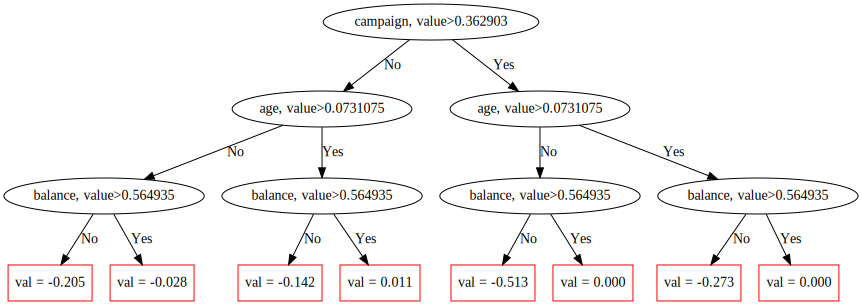

In [105]:
# Визуализация одного из деревьев CatBoost
train_pool_bin = Pool(X_bin_train, label=y_bin_train, cat_features = cat_cols_bin)

cb_model_f.plot_tree(3, train_pool_bin)

## 5. Регрессия:
   - С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели линейной регрессии с использованием $XGBoost$ или $CatBoost$.
     > [xgboost.XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor) в $XGBoost$, [CatBoostRegressor](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor) в $CatBoost$.
   - Вывести метрики $MSE$, $MAE$ и $R^2$ на тестовом наборе.
   - Осуществить фильтрацию признаков по аналогии с пунктом 4.
   - Переобучить модель на отфильтрованном наборе признаков.
   - Сравнить метрики до и после фильтрации.

In [8]:
train_pool_reg = Pool(X_reg_train, label=y_reg_train, cat_features = cat_cols_reg)
test_pool_reg = Pool(X_reg_test, label=y_reg_test, cat_features = cat_cols_reg)

In [141]:
cbr_model = CatBoostRegressor(random_state=0, logging_level='Silent')

cbr_grid_params = {
    'iterations': [150],
    'learning_rate': [0.01, 0.1, 1],
    'depth': [3, 4, 5, 7, 9],
    'l2_leaf_reg': [0.01, 0.1, 0.5, 1]
}

grid_result = cbr_model.grid_search(
    cbr_grid_params,
    X=train_pool_reg,
    cv=5,
    partition_random_seed=42,
    refit=True,
    verbose=False
)

y_pred = cbr_model.predict(test_pool_reg)

print(f"Лучшие гиперпараметры CatBoostRegressor:\n {grid_result['params']}")
print(f"\n--- Показатели на тестовой выборке --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred):.4f}")

Лучшие гиперпараметры CatBoostRegressor:
 {'depth': 5, 'learning_rate': 0.1, 'l2_leaf_reg': 0.01, 'iterations': 150}

--- Показатели на тестовой выборке --- 

MSE: 16.4551
MAE: 3.3583
R2: 0.1975


In [120]:
tree_explainer = shap.TreeExplainer(cbr_model)
te_df_shap_values = tree_explainer(X_reg_train)
te_reg_shap_values = tree_explainer.shap_values(X_reg_train)

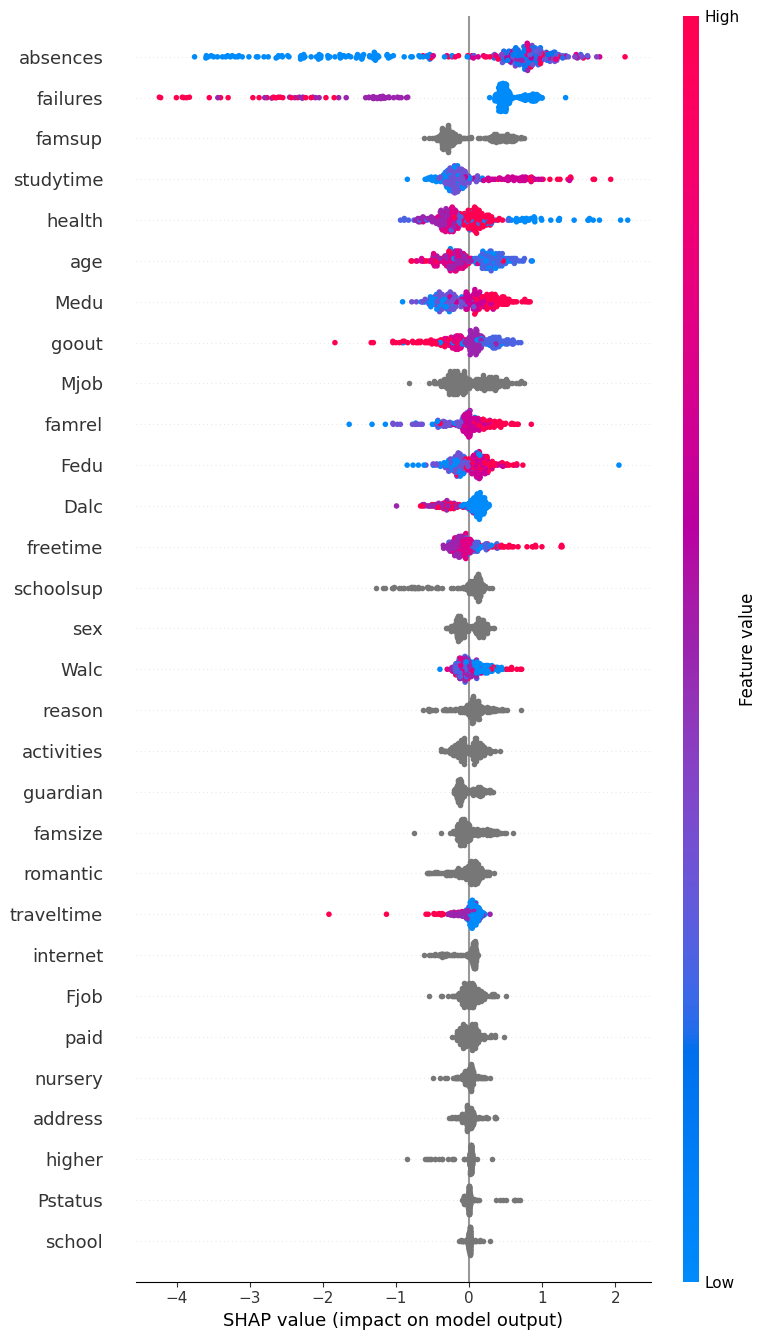

In [122]:
fig, ax = plt.subplots()
shap.plots.beeswarm(te_df_shap_values, max_display=X_reg_train.shape[1], show=False)
fig.tight_layout()

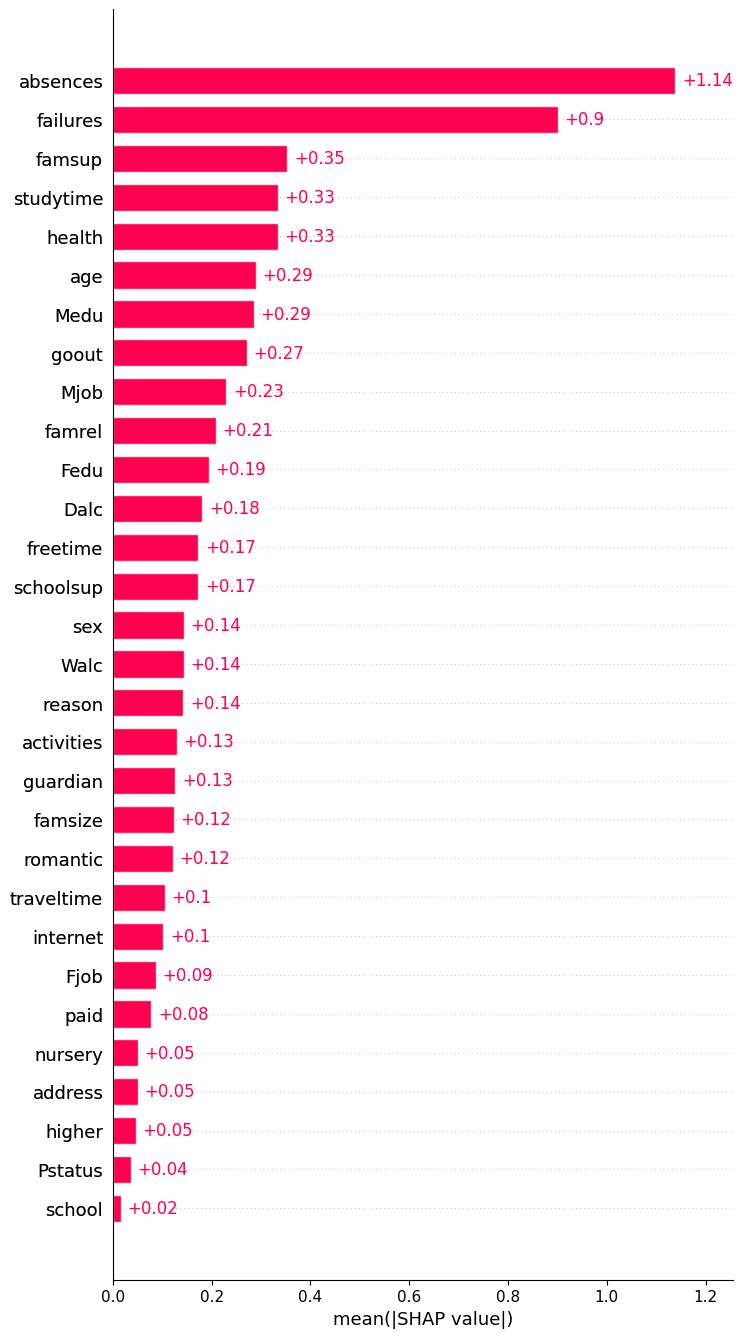

In [121]:
fig, ax = plt.subplots()

shap_bp = shap.plots.bar(te_df_shap_values, max_display=X_reg_train.shape[1])
fig.tight_layout()

**Отбор признаков**:

По `bar` графику видно, что наиболее важными признаками (по среднему значению **SHAP**) для принятия решений по тому, какую оценку получит в конце года ученик, являются **absenses** (число пропусков школы), **failures** (количество несданных ранее предметов), **famsup** (поддержка со стороны семьи), **studytime** (еженедельное время на учебу), **age** (возраст), **goout** (частота встреч с друзьями), **Mjob** (работа матери) и **famrel** (качество семейных отношений).

Отберем эти признаки и осуществим классификацию на них.

In [9]:
reg_cols_f = ['absences', 'failures', 'famsup', 'studytime', 'age', 'goout', 'Mjob', 'famrel']
reg_cat_cols_f = ['famsup', 'Mjob']

train_pool_reg_f = Pool(X_reg_train[reg_cols_f], label=y_reg_train, cat_features = reg_cat_cols_f)
test_pool_reg_f = Pool(X_reg_test[reg_cols_f], label=y_reg_test, cat_features = reg_cat_cols_f)

In [10]:
cbr_model = CatBoostRegressor(depth=5, learning_rate=0.1, l2_leaf_reg=0.01, iterations=1000, cat_features=cat_cols_reg)

cbr_model.fit(train_pool_reg, verbose=False)

y_pred = cbr_model.predict(test_pool_reg)

In [11]:
cbr_model_f = CatBoostRegressor(depth=5, learning_rate=0.1, l2_leaf_reg=0.01, iterations=1000, cat_features=reg_cat_cols_f)

cbr_model_f.fit(train_pool_reg_f, verbose=False)

y_pred_f = cbr_model_f.predict(test_pool_reg_f)

In [12]:
print(f"\n--- До фильтрации --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred):.4f}")

print(f"\n--- После фильтрации --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred_f):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_f):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred_f):.4f}")


--- До фильтрации --- 

MSE: 16.8857
MAE: 3.2751
R2: 0.1765

--- После фильтрации --- 

MSE: 18.5841
MAE: 3.4571
R2: 0.0937


Как видно, после фильтрации качество регрессии упало. Предположу, что это связано с тем, что мы отфильтровали слишком большое количество важных признаков. В целях проверки данного предположения отберем признаки еще раз, убрав из начального набора только совсем малоинформативные признаки, а не взяв только самые информативные.

In [15]:
cat_cols_reg

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [17]:
reg_cols_f2 = ['absences', 'failures', 'famsup', 'studytime', 'age',
              'goout', 'Mjob', 'famrel', 'Fedu', 'Dalc',
              'freetime', 'schoolsup', 'sex', 'Walc', 'reason',
              'activities', 'guardian', 'famsize', 'romantic']
reg_cat_cols_f2 = ['famsup', 'Mjob', 'schoolsup', 'sex', 'reason',
                   'guardian', 'activities', 'romantic', 'famsize']

train_pool_reg_f2 = Pool(X_reg_train[reg_cols_f2], label=y_reg_train, cat_features = reg_cat_cols_f2)
test_pool_reg_f2 = Pool(X_reg_test[reg_cols_f2], label=y_reg_test, cat_features = reg_cat_cols_f2)

In [22]:
cbr_model_f2 = CatBoostRegressor(depth=5, learning_rate=0.1, l2_leaf_reg=0.01, iterations=1000, cat_features=reg_cat_cols_f2)

cbr_model_f2.fit(train_pool_reg_f2, verbose=False)

y_pred_f2 = cbr_model_f2.predict(test_pool_reg_f2)

In [25]:
print(f"\n--- До фильтрации --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred):.4f}")

print(f"\n--- После первого вида фильтрации --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred_f):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_f):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred_f):.4f}")

print(f"\n--- После второго вида фильтрации --- \n")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred_f2):.4f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_f2):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred_f2):.4f}")


--- До фильтрации --- 

MSE: 16.8857
MAE: 3.2751
R2: 0.1765

--- После первого вида фильтрации --- 

MSE: 18.5841
MAE: 3.4571
R2: 0.0937

--- После второго вида фильтрации --- 

MSE: 17.5108
MAE: 3.2348
R2: 0.1460


Моя теория не оправдалась, при любой фильтрации признаков точность регрессии понижается. Предположу, что отбор признаков для `CatBoost` не имеет смысла, поскольку он и так обрабатывает шум в данных и выделяет максимум информации из признаков